# Sensitivity charts

## Mappings from dashboard json exports to chart labels and number formatting

In [44]:
import json
from pathlib import Path

# Per-metric display format (string templates)
format_val = {
  # Envelope (spread)
  "median_W":           "{:.1f}",     # absolute width (units of variable)
  "p90_W":              "{:.1f}",
  "RW_med":             "{:.0%}",     # relative width (median)
  "RW_high":            "{:.0%}",     # on event days
  "RW_low":             "{:.0%}",
  "Peak_ratio":         "{:.2f}×",

  # Central shift (displacement)
  "CS_abs":             "{:.1f}",     # absolute shift
  "CS_rel":             "{:.1%}",     # relative shift
  "Signed_C_shift":     "{:+.1%}",    # signed relative shift

  # Coverage
  "Coverage_frac":      "{:.0%}",
  "coverage100":        "{:.0%}",
  "Outside_upper":      "{:.0%}",
  "Outside_lower":      "{:.0%}",

  # Event contrast
  "Event_contrast":     "{:+.0%}",    # RW_high − RW_low (relative units)
  "Event_ratio":        "{:.2f}×",

  # Duration-curve signature
  "RA_5":               "{:.0%}",
  "RA_50":              "{:.0%}",
  "RA_95":              "{:.0%}",

  # Optional shift detail (from your table)
  "delta_mean":         "{:+.1f}",
  "median_delta":       "{:+.1f}",
  "median_delta_pct":   "{:+.0%}",
  "delta_min":          "{:+.1f}",
  "delta_p50":          "{:+.1f}",
  "delta_p90":          "{:+.1f}",
  "delta_max":          "{:+.1f}",
  "delta_event_pairs_mean": "{:+.1f}",
  "delta_non_event_pairs_mean": "{:+.1f}",
  "normalized_mean_delta": "{:+.1%}",

  # Bias metrics
  "PBIAS%": "{:+.0f}%",
  "Bias(obs-pred)": "{:+.1f}",

  # Alias/legacy keys (if used)
  "relative_width":      "{:.0%}",
  "relative_width_high": "{:.0%}",
  "relative_width_low":  "{:.0%}",
  "relative_width_event": "{:.0%}",
  "relative_width_nonevent": "{:.0%}",
  "relative_width_event_contrast": "{:+.0%}",
  "event_ratio": "{:.2f}×",
}

# Single source of truth for label selection.
#
# Each key is the technical metric name expected in the exported stats JSON.
# `label` is what you pass in semantic_labels.
# Add `path` only when that metric name appears in multiple places in the export JSON.
# Example: "path": ("overlay_comparison", "__baseline__", "relative_width")
semantic_label_map = {
  # Width & spread
  "median_W": {"label": "Model raw width median (W)"},
  "p90_W": {"label": "Model raw width p90 (W)"},
  "RW_med": {"path": ("overlay_comparison", "__baseline__", "relative_width"), "label": "Model relative width (min-max / median)"},
  "RW_high": {"label": "Relative width (event days)"},
  "RW_low": {"label": "Relative width (non-event days)"},

  # Shift & coverage
  "Coverage_frac": {"label": "Coverage fraction (overlay inside envelope)"},
  "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (baseline - overlay)"},
  "median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Shift median"},
  "delta_min": {"label": "Shift in min (baseline - overlay)"},
  "delta_p50": {"label": "Shift in p50 (baseline - overlay)"},
  "delta_p90": {"label": "Shift in p90 (baseline - overlay)"},
  "delta_max": {"label": "Shift in max (baseline - overlay)"},
  "delta_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_event_pairs_mean"), "label": "Shift events (mean)"},
  "delta_non_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_non_event_pairs_mean"), "label": "Shift non-events (mean)"},
  "normalized_mean_delta": {"label": "Normalized mean shift (delta / baseline mean)"},
  "coverage100": {"path": ("same_day", "coverage100"), "label": "Min/Max Coverage (observations inside envelope)"}, 


  # BIAS
  "PBIAS%": {"path": ("same_day", "PBIAS%"), "label": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
  "Bias(obs-pred)": {"path": ("same_day", "Bias(obs-pred)"), "label": "Bias (absolute) - sum(observed - simulated)"},


  # Event contrast (if used)
  "relative_width_event_contrast": {"label": "Event contrast (high / low)"},
  "event_ratio": {"label": "Event ratio (event / non-event)"},
  "relative_width_high": {"label": "Relative width high decile"},
  "relative_width_low": {"label": "Relative width low decile"},

}




### helper functions to convert data according to mappings

In [45]:
# Backwards-compatible flat view if you still want a technical-name -> label lookup elsewhere.
semantic_label = {
    technical_name: spec["label"]
    for technical_name, spec in semantic_label_map.items()
}

def _is_scalar_metric_value(value):
    """Return True for JSON scalar metric values that can be stored in the example dict."""
    return isinstance(value, (int, float)) and not isinstance(value, bool)


def _normalise_export_spec(export_spec):
    """
    Accept one export item in one of two forms:
      - {"path": ..., "scenario": ..., "variable": ...}
      - (path, scenario, variable)
    
    Variable can be omitted from the dict if the JSON file contains
    dashboard_state.variable, but scenario must always be supplied because it is
    not part of the current export payload.
    """
    if isinstance(export_spec, dict):
        path = export_spec.get("path")
        scenario = export_spec.get("scenario")
        variable = export_spec.get("variable")
    elif isinstance(export_spec, (tuple, list)) and len(export_spec) == 3:
        path, scenario, variable = export_spec
    else:
        raise TypeError(
            "Each export spec must be either a dict with keys 'path', 'scenario', 'variable' "
            "or a 3-item tuple/list of (path, scenario, variable)."
        )

    if not path:
        raise ValueError(f"Invalid export spec {export_spec!r}: missing file path.")
    if not scenario:
        raise ValueError(
            f"Invalid export spec {export_spec!r}: missing scenario. "
            "Scenario is not stored in the current JSON export, so it must be provided explicitly."
        )

    return Path(path), str(scenario), variable


def _load_stat_export(export_spec, *, verbose=True):
    """Load one JSON export file and return its payload plus resolved identifiers."""
    path, scenario, variable = _normalise_export_spec(export_spec)
    if verbose:
        print(f"Loading stats export: {path}")

    if not path.exists():
        raise FileNotFoundError(f"Stats export file does not exist: {path}")

    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if not isinstance(payload, dict):
        raise ValueError(f"Stats export {path} does not contain a top-level JSON object.")

    dashboard_state = payload.get("metadata", {}).get("dashboard_state") or payload.get("dashboard_state") or {}
    if variable is None:
        variable = dashboard_state.get("variable")

    if not variable:
        raise ValueError(
            f"Could not determine variable for {path}. "
            "Provide it explicitly in the export spec or ensure the payload has dashboard_state.variable."
        )

    stats = payload.get("stats")
    if not isinstance(stats, dict):
        raise ValueError(f"Stats export {path} is missing a 'stats' dictionary.")

    if verbose:
        print(f"  scenario={scenario}, variable={variable}")
    return {
        "path": path,
        "scenario": str(scenario),
        "variable": str(variable),
        "payload": payload,
        "stats": stats,
    }


def _normalise_semantic_entry(technical_name, entry):
    """Normalise one semantic_label_map entry to {'label': ..., 'path': ...}."""
    if isinstance(entry, str):
        spec = {"label": entry, "path": None}
    elif isinstance(entry, dict):
        label = entry.get("label")
        if not label or not isinstance(label, str):
            raise ValueError(
                f"semantic_label_map[{technical_name!r}] must define a string 'label'."
            )
        path = entry.get("path")
        if path is not None:
            if not isinstance(path, (tuple, list)) or not path or not all(isinstance(part, str) for part in path):
                raise ValueError(
                    f"semantic_label_map[{technical_name!r}]['path'] must be a non-empty tuple/list of strings."
                )
            path = tuple(path)
        spec = {"label": label, "path": path}
    else:
        raise TypeError(
            f"semantic_label_map[{technical_name!r}] must be either a label string or a dict with 'label' and optional 'path'."
        )

    return spec


def _normalise_semantic_label_map(semantic_label_map):
    """Return a validated semantic_label_map with uniform dict entries."""
    normalised = {}
    reverse_semantic_label = {}
    duplicate_labels = {}

    for technical_name, entry in semantic_label_map.items():
        spec = _normalise_semantic_entry(technical_name, entry)
        label = spec["label"]
        if label in reverse_semantic_label and reverse_semantic_label[label] != technical_name:
            duplicate_labels.setdefault(label, set()).update([reverse_semantic_label[label], technical_name])
        reverse_semantic_label[label] = technical_name
        normalised[technical_name] = spec

    if duplicate_labels:
        raise ValueError(
            "semantic_label_map contains duplicate labels mapped to different technical names: "
            f"{ {label: sorted(names) for label, names in duplicate_labels.items()} }"
        )

    return normalised


def _find_metric_matches(node, technical_name, path=()):
    """
    Recursively search the exported stats dictionary for a technical metric key.

    Returns a list of (path_tuple, value) matches so ambiguous metrics can be
    reported clearly instead of silently choosing the wrong number.
    """
    matches = []

    if isinstance(node, dict):
        for key, value in node.items():
            next_path = path + (str(key),)
            if key == technical_name and _is_scalar_metric_value(value):
                matches.append((next_path, value))
            matches.extend(_find_metric_matches(value, technical_name, next_path))

    elif isinstance(node, list):
        for index, value in enumerate(node):
            matches.extend(_find_metric_matches(value, technical_name, path + (str(index),)))

    return matches


def _extract_metric_value(stats_dict, technical_name, explicit_path=None, *, verbose=True):
    """Extract one metric value from the exported stats dictionary."""
    if explicit_path is not None:
        explicit_path = tuple(explicit_path)
        current = stats_dict
        for part in explicit_path:
            if not isinstance(current, dict) or part not in current:
                raise KeyError(
                    f"Explicit path {explicit_path!r} for '{technical_name}' does not exist in the stats export."
                )
            current = current[part]
        if not _is_scalar_metric_value(current):
            raise ValueError(
                f"Explicit path {explicit_path!r} for '{technical_name}' does not resolve to a numeric scalar."
            )
        if verbose:
            print(f"    using semantic_label_map path {explicit_path} -> {current}")
        return current

    matches = _find_metric_matches(stats_dict, technical_name)
    if not matches:
        raise KeyError(
            f"Metric '{technical_name}' was not found anywhere in the stats export. "
            "If it is nested under an ambiguous branch, add a 'path' entry in semantic_label_map for it."
        )
    if len(matches) > 1:
        pretty_paths = [" -> ".join(path) for path, _ in matches]
        raise ValueError(
            f"Metric '{technical_name}' matched more than one location in the stats export: {pretty_paths}. "
            "Add a 'path' entry to semantic_label_map for this metric."
        )

    metric_path, metric_value = matches[0]
    if verbose:
        print(f"    found {technical_name} at {' -> '.join(metric_path)} = {metric_value}")
    return metric_value


def _format_metric_value(value, fmt, technical_name):
    """Render one numeric value with the metric format string."""
    try:
        return fmt.format(value)
    except Exception as exc:
        raise ValueError(
            f"Could not format value {value!r} for metric '{technical_name}' with format {fmt!r}."
        ) from exc


def _build_requested_metric_specs(semantic_labels, semantic_label_map, format_map):
    """Resolve requested labels to technical names, formats, and optional paths."""
    reverse_semantic_label = {
        spec["label"]: technical_name
        for technical_name, spec in semantic_label_map.items()
    }

    requested_specs = []
    for requested_label in semantic_labels:
        if requested_label in reverse_semantic_label:
            technical_name = reverse_semantic_label[requested_label]
            output_label = requested_label
        elif requested_label in semantic_label_map:
            technical_name = requested_label
            output_label = semantic_label_map[requested_label]["label"]
        else:
            available = sorted(reverse_semantic_label.keys())
            raise KeyError(
                f"Unknown semantic label or technical name: {requested_label!r}. "
                f"Available semantic labels include: {available}"
            )

        if technical_name not in format_map:
            raise KeyError(
                f"No format string found in format_val for technical metric '{technical_name}'. "
                "Add it to format_val before building the metrics dictionary."
            )

        requested_specs.append(
            {
                "technical_name": technical_name,
                "output_label": output_label,
                "format": format_map[technical_name],
                "path": semantic_label_map[technical_name].get("path"),
            }
        )

    return requested_specs


def build_metrics_dict_from_stat_exports(
    export_specs,
    semantic_labels,
    *,
    semantic_label_map=None,
    format_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=True,
):
    """
    Build a dict with the same structure as the example 'metrics' blocks from a
    list of dashboard JSON exports.

    Parameters
    ----------
    export_specs : list
        One item per scenario-variable combination. Recommended form:
            {"path": <json_path>, "scenario": "WASTE", "variable": "TP"}
        A tuple/list of (path, scenario, variable) also works.

    semantic_labels : list[str]
        Labels you want in the output dictionary, using the labels defined in
        semantic_label_map, for example:
            ["Median width", "Coverage", "Mean Δ"]
        Technical keys are also accepted directly.

    semantic_label_map : dict, optional
        Mapping of technical metric names to config dicts with:
            - 'label': display label used in semantic_labels
            - 'path' : optional explicit path inside the exported stats dict
        A plain string value is also accepted as shorthand for {'label': <string>}.

    format_map : dict, optional
        Mapping of technical metric names to format strings. If a technical name
        has no format entry, the function raises a helpful error.

    scenario_order / variable_order : list, optional
        If omitted, the function uses the order in which scenarios and variables
        appear in export_specs.

    include_technical_names : bool, default False
        If True, each output metric also gets a '__technical_name' field.

    format_mode : {'metadata', 'values'}, default 'metadata'
        'metadata' keeps numeric values and adds '__format'.
        'values' applies the format string to each extracted value and omits '__format'.

    verbose : bool, default True
        Print progress information while reading files and extracting metrics.

    Returns
    -------
    dict
        A dictionary shaped like:
            {
                "metrics": {
                    "Median width": {
                        "__format": "{:.1f}",
                        "WASTE": {"TP": 12.8, "TKN": 17.6},
                        ...
                    },
                    ...
                }
            }
    """
    if semantic_label_map is None:
        semantic_label_map = globals()["semantic_label_map"]
    semantic_label_map = _normalise_semantic_label_map(semantic_label_map)

    if format_map is None:
        format_map = format_val

    valid_format_modes = {"metadata", "values"}
    if format_mode not in valid_format_modes:
        raise ValueError(
            f"format_mode must be one of {sorted(valid_format_modes)}, got {format_mode!r}."
        )

    if not export_specs:
        raise ValueError("export_specs is empty. Provide one export spec per scenario-variable combination.")
    if not semantic_labels:
        raise ValueError("semantic_labels is empty. Provide at least one label to extract.")

    loaded_exports = []
    seen_scenarios = []
    seen_variables = []

    if verbose:
        print(f"Preparing to read {len(export_specs)} stats export files...")

    for export_spec in export_specs:
        loaded = _load_stat_export(export_spec, verbose=verbose)
        loaded_exports.append(loaded)
        if loaded["scenario"] not in seen_scenarios:
            seen_scenarios.append(loaded["scenario"])
        if loaded["variable"] not in seen_variables:
            seen_variables.append(loaded["variable"])

    scenario_order = list(scenario_order) if scenario_order is not None else seen_scenarios
    variable_order = list(variable_order) if variable_order is not None else seen_variables

    if verbose:
        print(f"Scenarios discovered: {scenario_order}")
        print(f"Variables discovered: {variable_order}")

    requested_specs = _build_requested_metric_specs(
        semantic_labels,
        semantic_label_map,
        format_map,
    )

    result = {"metrics": {}}
    for spec in requested_specs:
        output_label = spec["output_label"]
        metric_block = {}
        if format_mode == "metadata":
            metric_block["__format"] = spec["format"]
        if include_technical_names:
            metric_block["__technical_name"] = spec["technical_name"]
        for scenario in scenario_order:
            metric_block[scenario] = {}
        result["metrics"][output_label] = metric_block

    for loaded in loaded_exports:
        scenario = loaded["scenario"]
        variable = loaded["variable"]
        stats_dict = loaded["stats"]

        if scenario not in scenario_order:
            raise ValueError(
                f"Scenario '{scenario}' from {loaded['path']} is not present in scenario_order {scenario_order}."
            )
        if variable not in variable_order:
            raise ValueError(
                f"Variable '{variable}' from {loaded['path']} is not present in variable_order {variable_order}."
            )

        if verbose:
            print(f"Reading metrics for scenario={scenario}, variable={variable}")

        for spec in requested_specs:
            raw_value = _extract_metric_value(
                stats_dict,
                spec["technical_name"],
                explicit_path=spec["path"],
                verbose=verbose,
            )
            if format_mode == "values":
                final_value = _format_metric_value(
                    raw_value,
                    spec["format"],
                    spec["technical_name"],
                )
            else:
                final_value = raw_value
            result["metrics"][spec["output_label"]][scenario][variable] = final_value

    missing_entries = []
    for output_label in result["metrics"]:
        for scenario in scenario_order:
            for variable in variable_order:
                if variable not in result["metrics"][output_label][scenario]:
                    missing_entries.append((output_label, scenario, variable))

    if missing_entries:
        preview = ", ".join([f"{label}/{scenario}/{variable}" for label, scenario, variable in missing_entries[:8]])
        suffix = " ..." if len(missing_entries) > 8 else ""
        raise ValueError(
            "The assembled metrics dictionary is incomplete. Missing entries: "
            f"{preview}{suffix}"
        )

    if verbose:
        print("Finished building metrics dictionary.")
        print(f"Built {len(result['metrics'])} metrics across {len(scenario_order)} scenarios and {len(variable_order)} variables.")

    return result

## Different CHART layouts

### Horizontal stacking of metrics

In [46]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

def plot_nested_sensitivity_bars(
    stats_data,
    stats_order=None,
    title="Sensitivity metrics (nested bar chart)",
    y_label="Value",
    figsize=(14, 7),
    abbreviations=None,
    value_format=None,          # callable: (v) or (v, stat) -> str
    annotate_decimals=1,        # used only if neither per-metric nor format_map nor value_format is provided
    format_map=None,            # optional: dict {metric_key: format_string}
    bar_alpha=0.85,
    annotate_rotation=45,
    scenario_label_rotation=45,
    scenario_spacing=0.06,
    bar_width=0.12,
    bottom_margin_for_labels=0.12,
    stat_label_map=None         # optional: {metric_key: display_label}
    # (legend placement adjusted: now inside axes)
    # NOTE: if legend overlaps data, reduce fig size or adjust top_pad.
    # Keep signature minimal per request.
    # You can extend with legend_loc parameter later if desired.
    ):
    """
    stats_data["metrics"][<STAT>][SCENARIO][VAR] -> float
    Scenarios fixed: WASTE, SOIL, WASTE+SOIL
    Variables fixed: TP, TKN

    Optional per-metric meta-keys inside each <STAT> block:
      • "__format": format string, e.g., "{:.0%}", "{:.1f}", "{:.2f}×"
      • "__label" : short display label for the x-axis; overrides stat_label_map for this stat
    """
    scenarios = ["WASTE", "SOIL", "WASTE+SOIL"]
    variables = ["TP", "TKN"]

    if abbreviations is None:
        abbreviations = {"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S"}

    if value_format is not None and not callable(value_format):
        raise TypeError("value_format must be a callable, e.g. lambda v: '...'. You passed a non-callable.")

    # Prepare a safe formatter wrapper; will be used only if no per-metric or format_map string is found
    if value_format is None:
        fmt_str_default = "{:." + str(int(max(0, annotate_decimals))) + "f}"
        def _format_value(v, stat=None):
            return fmt_str_default.format(v)
    else:
        _orig_fmt = value_format
        def _format_value(v, stat=None):
            # support (v) or (v, stat)
            try:
                return _orig_fmt(v)
            except TypeError:
                return _orig_fmt(v, stat)

    metrics = stats_data.get("metrics", {})
    if not isinstance(metrics, dict) or not metrics:
        raise ValueError("stats_data must contain a non-empty dict at 'metrics'.")

    # Validate presence of scenarios/variables ignoring meta-keys
    def _validate_stat(stat_name, block):
        missing = []
        for sc in scenarios:
            if sc not in block:
                missing.append(f"scenario '{sc}'")
            else:
                for var in variables:
                    if var not in block[sc]:
                        missing.append(f"{sc}→'{var}'")
        if missing:
            raise ValueError(f"Metric '{stat_name}' is missing: {', '.join(missing)}")

    for s, block in metrics.items():
        if not isinstance(block, dict):
            raise ValueError(f"Metric '{s}' must map to a dict.")
        _validate_stat(s, block)

    # Order of metrics
    if stats_order is None:
        stats = list(metrics.keys())
    else:
        if not isinstance(stats_order, (list, tuple)):
            raise TypeError("stats_order must be a list/tuple of metric keys.")
        extra = [s for s in stats_order if s not in metrics]
        if extra:
            raise ValueError(f"stats_order contains unknown metric keys: {extra}")
        stats = list(stats_order)

    # Build display labels: per-metric "__label" > stat_label_map > key
    stat_labels = []
    for s in stats:
        block = metrics[s]
        if isinstance(block, dict) and "__label" in block:
            stat_labels.append(block["__label"])
        elif isinstance(stat_label_map, dict) and s in stat_label_map:
            stat_labels.append(stat_label_map[s])
        else:
            stat_labels.append(s)

    # Layout math
    n_stats = len(stats)
    bars_per_subgroup = len(variables)
    subgroup_width = bars_per_subgroup * bar_width
    group_inner = len(scenarios) * subgroup_width + (len(scenarios) - 1) * scenario_spacing
    group_width = group_inner + 0.35

    fig, ax = plt.subplots(figsize=figsize)
    var_to_color = {"TP": "#1f77b4", "TKN": "#ff7f0e"}
    global_max = -math.inf

    for i, stat in enumerate(stats):
        block = metrics[stat]
        # Resolve per-metric format string if present (inline first, then format_map)
        per_metric_fmt = None
        if "__format" in block:
            per_metric_fmt = block["__format"]
        elif isinstance(format_map, dict) and stat in format_map:
            per_metric_fmt = format_map[stat]

        for j, scenario in enumerate(scenarios):
            subgroup_left = i * group_width + j * (subgroup_width + scenario_spacing)

            for k, var in enumerate(variables):
                x = subgroup_left + k * bar_width
                y = float(block[scenario][var])
                global_max = max(global_max, y)
                ax.bar(x, y, width=bar_width, color=var_to_color[var], alpha=bar_alpha)

                # Decide label text using precedence:
                # inline per-metric "__format" > format_map > value_format/_format_value > annotate_decimals fallback
                if isinstance(per_metric_fmt, str):
                    try:
                        label_txt = per_metric_fmt.format(y)
                    except Exception:
                        label_txt = str(y)
                else:
                    label_txt = _format_value(y, stat)

                ax.text(
                    x, y + (0.015 * max(1.0, global_max)),
                    label_txt, ha="center", va="bottom",
                    rotation=annotate_rotation, fontsize=8
)

            # Scenario label under subgroup
            subgroup_center = subgroup_left + (subgroup_width - bar_width) / 2
            ax.text(
                subgroup_center, -0.04 * max(1.0, global_max),
                abbreviations.get(scenario, scenario),
                ha="center", va="top", rotation=scenario_label_rotation, fontsize=8
)

    # X ticks & labels
    xticks = [i * group_width + group_inner / 2 for i in range(n_stats)]
    ax.set_xticks(xticks)
    ax.set_xticklabels(stat_labels, fontsize=10)

    ax.set_ylabel(y_label)
    ax.set_title(title)

    # Legend: variable color swatches + scenario abbreviation mapping reversed (abbr = full)
    handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
    labels = list(variables)
    # Append scenario abbreviation mappings (no color box)
    for full_name, abbr in abbreviations.items():
        # reversed order: show 'ABBR = FULL'
        handles.append(Line2D([0], [0], color='none'))
        labels.append(f"{abbr} = {full_name}")
    ax.legend(handles, labels, title="Variables / Scenarios", loc="upper right", frameon=True, handlelength=1.2)

    top_pad = 0.12 * max(1.0, global_max)
    bottom_pad = bottom_margin_for_labels * max(1.0, global_max)
    ax.set_ylim(bottom=-bottom_pad, top=global_max + top_pad)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    return fig, ax


### Vertical stacking of metrics

In [47]:
from matplotlib.patches import Rectangle

def _normalise_three_metric_specs(metric_specs):
    """Return the ordered semantic labels requested by the simplified comparison plot."""
    if metric_specs is None:
        metric_specs = [
            {"title": "Min/Max Coverage (observations inside envelope)"},
            {"title": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
            {"title": "Bias (absolute) - sum(observed - simulated)"},
        ]

    if len(metric_specs) != 3:
        raise ValueError("metric_specs must contain exactly 3 metric definitions.")

    normalised_specs = []
    for spec in metric_specs:
        if isinstance(spec, str):
            normalised_specs.append({"title": spec})
        elif isinstance(spec, dict) and isinstance(spec.get("title"), str):
            normalised_specs.append(dict(spec))
        else:
            raise TypeError(
                "Each metric spec must be either a label string or a dict containing a string 'title'."
            )

    return normalised_specs


def build_three_metric_stats(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=False,
):
    """Build the stats dict consumed by the simplified three-metric plot."""
    semantic_labels = [spec["title"] for spec in _normalise_three_metric_specs(metric_specs)]
    return build_metrics_dict_from_stat_exports(
        export_specs,
        semantic_labels,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        include_technical_names=include_technical_names,
        format_mode=format_mode,
        verbose=verbose,
    )


def plot_three_metric_comparison(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    title="Three metric comparison",
    y_label="Value",
    figsize=(12, 9),
    abbreviations=None,
    scenario_short=None,
    var_color=None,
    bar_width=0.18,
    group_padding=0.5,
    bar_alpha=0.85,
    annot_fs=9,
    tick_fs=10,
    title_fs=12,
    label_fs=11,
    legend_fs=10,
    height_scale=0.85,
    annotate_rotation=35,
    format_mode="metadata",
    verbose=False,
):
    """
    Build three metric blocks from dashboard exports and plot them as three stacked
    subplots, preserving the original layout.

    metric_specs[*]['title'] is assumed to match labels defined in semantic_label_map.
    """
    if format_mode != "metadata":
        raise ValueError(
            "plot_three_metric_comparison requires format_mode='metadata' so the plot can keep numeric values "
            "and use '__format' for annotations."
        )

    normalised_specs = _normalise_three_metric_specs(metric_specs)
    semantic_labels = [spec["title"] for spec in normalised_specs]

    stats = build_three_metric_stats(
        export_specs,
        metric_specs=normalised_specs,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        format_mode=format_mode,
        verbose=verbose,
    )

    metrics = stats["metrics"]
    scenarios = list(scenario_order or ["WASTE", "SOIL", "WASTE+SOIL"])
    variables = list(variable_order or ["TP", "TKN"])

    if scenario_short is None:
        scenario_short = abbreviations or {"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S"}
    if var_color is None:
        var_color = {"TP": "#1f77b4", "TKN": "#ff7f0e"}

    subgroup_width = len(variables) * bar_width
    group_width = subgroup_width + group_padding

    def group_left(i_scn):
        return i_scn * group_width

    def bar_x(i_scn, i_var):
        return group_left(i_scn) + i_var * bar_width

    def group_center(i_scn):
        return group_left(i_scn) + (subgroup_width - bar_width) / 2

    fig, axes = plt.subplots(len(normalised_specs), 1, figsize=figsize, sharex=True)
    if len(normalised_specs) == 1:
        axes = [axes]

    for idx, spec in enumerate(normalised_specs):
        metric_label = spec["title"]
        metric_block = metrics[metric_label]
        metric_fmt = metric_block.get("__format", "{:.1f}")
        ax = axes[idx]

        values = [float(metric_block[scenario][variable]) for scenario in scenarios for variable in variables]
        y_min = min(values)
        y_max = max(values)

        signed = y_min < 0
        if signed:
            ax.axhline(0, color="black", linewidth=0.8)

        ymax_abs = max(1.0, abs(y_max))
        ymin_abs = min(-1.0 if signed else 0.0, y_min)
        top_pad = 0.15 * ymax_abs
        bottom_pad = 0.18 * max(1.0, abs(ymin_abs))
        ax.set_ylim(bottom=ymin_abs - bottom_pad, top=ymax_abs + top_pad)

        for i_scn, scenario in enumerate(scenarios):
            for i_var, variable in enumerate(variables):
                raw_value = float(metric_block[scenario][variable])
                scaled_value = raw_value * height_scale
                x = bar_x(i_scn, i_var)
                ax.bar(x, scaled_value, width=bar_width, color=var_color[variable], alpha=bar_alpha)

                offset = 0.015 * max(1.0, abs(raw_value))
                if raw_value >= 0:
                    ax.text(x, scaled_value + offset, metric_fmt.format(raw_value), ha="center", va="bottom", fontsize=annot_fs)
                else:
                    ax.text(x, scaled_value - offset, metric_fmt.format(raw_value), ha="center", va="top", fontsize=annot_fs)

        xticks = [group_center(i) for i in range(len(scenarios))]
        ax.set_xticks(xticks)
        ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=annotate_rotation)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        ax.set_title(metric_label, fontsize=title_fs)
        ax.set_ylabel(y_label, fontsize=label_fs)
        ax.tick_params(axis="y", labelsize=tick_fs)

    handles = [Rectangle((0, 0), 1, 1, color=var_color[variable]) for variable in variables]
    fig.legend(
        handles,
        variables,
        title="Variables",
        loc="upper left",
        bbox_to_anchor=(0.085, 0.96),
        fontsize=legend_fs,
        title_fontsize=legend_fs,
    )

    fig.suptitle(title, fontsize=title_fs + 1)
    plt.tight_layout(rect=[0.0, 0.02, 0.96, 0.96])
    return fig, axes, stats

# Charts

In [48]:
# Suggested ordering in the chart:
stats_order_first_ch = [
  "Total median width",
  "Relative width (min–max/median)",
  "Event width",
  "Non-event width",
  "Coverage fraction",
] 

#format only coverage as percent:
value_format_map = {
  "Coverage fraction": (lambda v: f"{v*100:.1f}%")
}

In [49]:
# Example: build a metrics dictionary directly from dashboard JSON exports.
#
# This example uses real files from the multi-variable batch export folder so the
# scenario/variable grid is complete for WASTE, SOIL, and WASTE+SOIL across TP and TKN.

example_export_specs = [
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-200_var-tot-pkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "WASTE",
        "variable": "TP",
    },
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-200_var-kjeldahl-outkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "WASTE",
        "variable": "TKN",
    },
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-201_var-tot-pkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "SOIL",
        "variable": "TP",
    },
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-201_var-kjeldahl-outkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "SOIL",
        "variable": "TKN",
    },
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-202_var-tot-pkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "WASTE+SOIL",
        "variable": "TP",
    },
    {
        "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_200_201_202__vars_kjeldahl_outkg_tot_pkg\run-202_var-kjeldahl-outkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json",
        "scenario": "WASTE+SOIL",
        "variable": "TKN",
    },
]

# Exact json structure for the current stats exports. Useful to extend or overwrite the semantic_label_map with new technical keys and paths as needed.
# For example: These width metrics are extracted from the current overlay comparison groups within the JSON exports.
example_semantic_label_map = {
    **semantic_label_map,
    "RW_high": {
        "label": "Relative width (event days)",
        "path": ("overlay_comparison", "BASE", "relative_width_event"),
    },
    "RW_low": {
        "label": "Relative width (non-event days)",
        "path": ("overlay_comparison", "BASE", "relative_width_nonevent"),
    },
}







In [50]:
def _normalise_selector_token(value):
    """Normalise exported variable tokens so mappings stay robust."""
    import re
    
    return re.sub(r"[^0-9a-z]+", "-", str(value).strip().lower()).strip("-")


def _extract_run_and_variable_from_stats_filename(filename):
    """Extract the run number and exported variable token from a stats filename."""
    import re
    
    match = re.search(r"run-(\d+)_var-(.+?)_reach", filename)
    if not match:
        return None, None
    return int(match.group(1)), _normalise_selector_token(match.group(2))


def _normalise_run_to_scenario(run_to_scenario):
    """Validate and normalise the run -> scenario mapping."""
    if not isinstance(run_to_scenario, dict):
        raise TypeError("run_to_scenario must be a dict mapping run_number -> scenario.")

    if not run_to_scenario:
        raise ValueError("run_to_scenario is empty")

    normalised = {}
    for run_id, scenario in run_to_scenario.items():
        if not scenario:
            raise ValueError(f"run_to_scenario[{run_id}] is missing a scenario value.")
        normalised[int(run_id)] = str(scenario)

    return normalised


def _normalise_variable_map(variable_map):
    """Validate and normalise the exported-variable -> output-variable mapping."""
    if not isinstance(variable_map, dict):
        raise TypeError(
            "variable_map must be a dict mapping exported variable tokens to output variable names."
        )

    if not variable_map:
        raise ValueError("variable_map is empty")

    return {
        _normalise_selector_token(export_variable): str(output_variable)
        for export_variable, output_variable in variable_map.items()
    }


def build_export_specs_from_folder(
    folder_path,
    run_to_scenario,
    variable_map,
    *,
    file_pattern="run-*.json",
    strict=False,
    verbose=True,
):
    """
    Generate export specs from a folder of dashboard stats JSON files.
    
    Each filename is parsed as:
        run-<RUN>_var-<EXPORTED_VARIABLE>_reach-...json
    
    The caller provides two flat mappings:
        - run_to_scenario : run number -> scenario
        - variable_map    : exported variable token -> output chart variable
    
    Expected mapping shape
    ----------------------
    run_to_scenario = {
        200: "WASTE",
        201: "SOIL",
        202: "WASTE+SOIL",
    }
    
    variable_map = {
        "tot-pkg": "TP",
        "kjeldahl-outkg": "TKN",
    }
    
    Returns a list of dicts shaped like:
        {"path": <json_path>, "scenario": <scenario>, "variable": <output_variable>}
    """
    folder = Path(folder_path)
    if not folder.is_dir():
        raise NotADirectoryError(f"Folder not found: {folder}")

    normalised_run_to_scenario = _normalise_run_to_scenario(run_to_scenario)
    normalised_variable_map = _normalise_variable_map(variable_map)

    json_files = sorted(folder.glob(file_pattern))
    if not json_files:
        raise FileNotFoundError(f"No files matching '{file_pattern}' found in {folder}")

    if verbose:
        print(f"Found {len(json_files)} JSON files in {folder}")

    export_specs = []
    failures = []

    for json_path in json_files:
        run_id, export_variable = _extract_run_and_variable_from_stats_filename(json_path.name)
        if run_id is None or export_variable is None:
            message = f"Could not parse run/variable from filename: {json_path.name}"
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        scenario = normalised_run_to_scenario.get(run_id)
        if scenario is None:
            message = f"Run {run_id} from {json_path.name} is not present in run_to_scenario."
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        output_variable = normalised_variable_map.get(export_variable)
        if output_variable is None:
            available = sorted(normalised_variable_map.keys())
            message = (
                f"Export variable '{export_variable}' from {json_path.name} is not mapped. "
                f"Available variable_map keys: {available}"
            )
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        export_specs.append({
            "path": str(json_path),
            "scenario": scenario,
            "variable": output_variable,
        })

        if verbose:
            print(
                f"  ✓ run-{run_id}: export_variable={export_variable}, "
                f"scenario={scenario}, variable={output_variable}"
            )

    matched_runs = {
        _extract_run_and_variable_from_stats_filename(Path(spec["path"]).name)[0]
        for spec in export_specs
    }
    missing_runs = sorted(set(normalised_run_to_scenario) - matched_runs)
    if missing_runs and verbose:
        print(f"  Note: no matched files were exported for runs: {missing_runs}")

    if failures:
        raise ValueError("Could not build export specs from folder:\n- " + "\n- ".join(failures))

    if verbose:
        print(f"\nBuilt {len(export_specs)} export specs")

    return export_specs


In [65]:
# Example usage: build export specs from a batch export folder

batch_folder = Path(
    # orig TFM
    #r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_153_155_157__vars_kjeldahl_outkg_tot_pkg"
    
    # csv_p75_absolute_relative_error
    # r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_188_200_201__vars_kjeldahl_outkg_tot_pkg"
    
    # csv_median_relative_error
    #r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_187_200_202__vars_kjeldahl_outkg_tot_pkg"
    
    # rmse_rel_center
    r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_189_200_203__vars_kjeldahl_outkg_tot_pkg"
 )

run_to_scenario = {
    200: "WASTE",
    201: "SOIL",
    202: "WASTE+SOIL",

    200: "WASTE",
    188: "SOIL",
    201: "WASTE+SOIL",

    200: "WASTE",
    187: "SOIL",
    202: "WASTE+SOIL",

    200: "WASTE",
    189: "SOIL",
    203: "WASTE+SOIL",

    157: "WASTE",
    153: "SOIL",
    155: "WASTE+SOIL",

}

variable_map = {
    "kjeldahl-outkg": "TKN",
    "tot-pkg": "TP",
}

generated_specs = build_export_specs_from_folder(
    batch_folder,
    run_to_scenario,
    variable_map,
    verbose=True,
 )

print(f"\nGenerated {len(generated_specs)} specs from {batch_folder.name}:")
for i, spec in enumerate(generated_specs, 1):
    print(f"  {i}. File: {Path(spec['path']).name}")
    print(f"     Scenario: {spec['scenario']}, Variable: {spec['variable']}")


Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_189_200_203__vars_kjeldahl_outkg_tot_pkg
  ✓ run-189: export_variable=kjeldahl-outkg, scenario=SOIL, variable=TKN
  ✓ run-189: export_variable=tot-pkg, scenario=SOIL, variable=TP
  ✓ run-200: export_variable=kjeldahl-outkg, scenario=WASTE, variable=TKN
  ✓ run-200: export_variable=tot-pkg, scenario=WASTE, variable=TP
  ✓ run-203: export_variable=kjeldahl-outkg, scenario=WASTE+SOIL, variable=TKN
  ✓ run-203: export_variable=tot-pkg, scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 188, 201, 202]

Built 6 export specs

Generated 6 specs from runs_189_200_203__vars_kjeldahl_outkg_tot_pkg:
  1. File: run-189_var-kjeldahl-outkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json
     Scenario: SOIL, Variable: TKN
  2. File: run-189_var-

In [66]:
print(generated_specs)

[{'path': 'C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\config\\outputs\\dashboard_stats\\runs_189_200_203__vars_kjeldahl_outkg_tot_pkg\\run-189_var-kjeldahl-outkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json', 'scenario': 'SOIL', 'variable': 'TKN'}, {'path': 'C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\config\\outputs\\dashboard_stats\\runs_189_200_203__vars_kjeldahl_outkg_tot_pkg\\run-189_var-tot-pkg_reach-13_freq-1d_method-mean_mode-load_view-all_19810101-20200101.json', 'scenario': 'SOIL', 'variable': 'TP'}, {'path': 'C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\config\\outputs\\dashboard_stats\\runs_189_200_203__vars_kjeldahl_outkg_tot_pkg\\run-200_var-kjeldahl-outkg_reach-13_freq

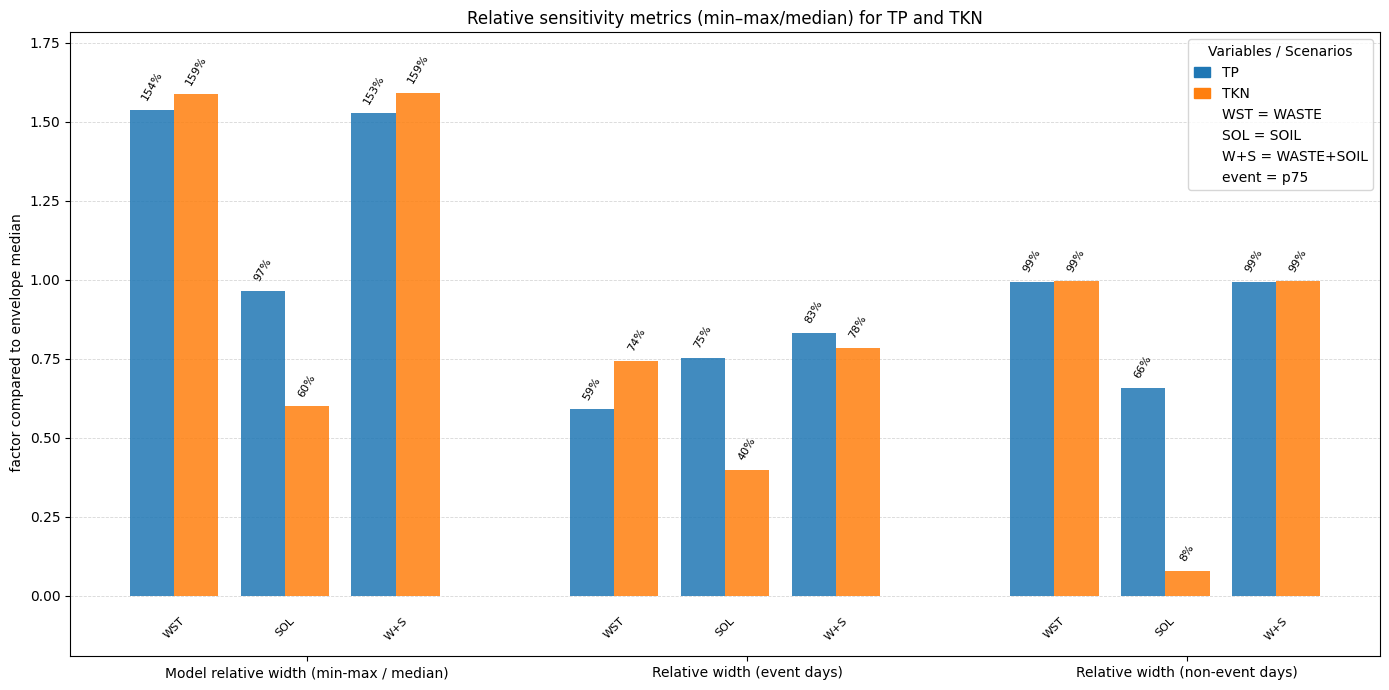

In [67]:
# Optional: display names (if you want shorter labels); otherwise omit stat_label_map


# Ask for metrics using the human-readable labels from semantic_label_map.
ch1_semantic_labels = [
    "Model relative width (min-max / median)",
    "Relative width (event days)",
    "Relative width (non-event days)",
]

# format_mode options:
# - "metadata": keep numeric values and add '__format' to each metric block.
# - "values": store formatted strings directly and omit '__format'.

ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
    generated_specs, #generated_specs, example_export_specs,
    ch1_semantic_labels,
    semantic_label_map=example_semantic_label_map,
    scenario_order=["WASTE", "SOIL", "WASTE+SOIL"],
    variable_order=["TP", "TKN"],
    format_mode="metadata",
    #format_mode="values",
    verbose=False,
 )


stats = ch_1_auto_metrics  # or ch_1


stat_display_names = {k: k for k in stats["metrics"].keys()}

fig, ax = plot_nested_sensitivity_bars(
    stats,
    # stats_order=stats_order_first_ch,  # optional
    title="Relative sensitivity metrics (min–max/median) for TP and TKN",
    y_label=" factor compared to envelope median",
    figsize=(14, 7),
    abbreviations={"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S", "p75":"event"},
    #value_format=lambda v: f"{v:.1f}",   # or omit and use annotate_decimals
    #annotate_decimals=2,
    #format_map=format_val,
    #bar_alpha=0.85,
    annotate_rotation=60,
    #scenario_label_rotation=45,
    #scenario_spacing=0.06,
    #bar_width=0.12,
    #bottom_margin_for_labels=0.12,
    #stat_label_map=stat_display_names
)


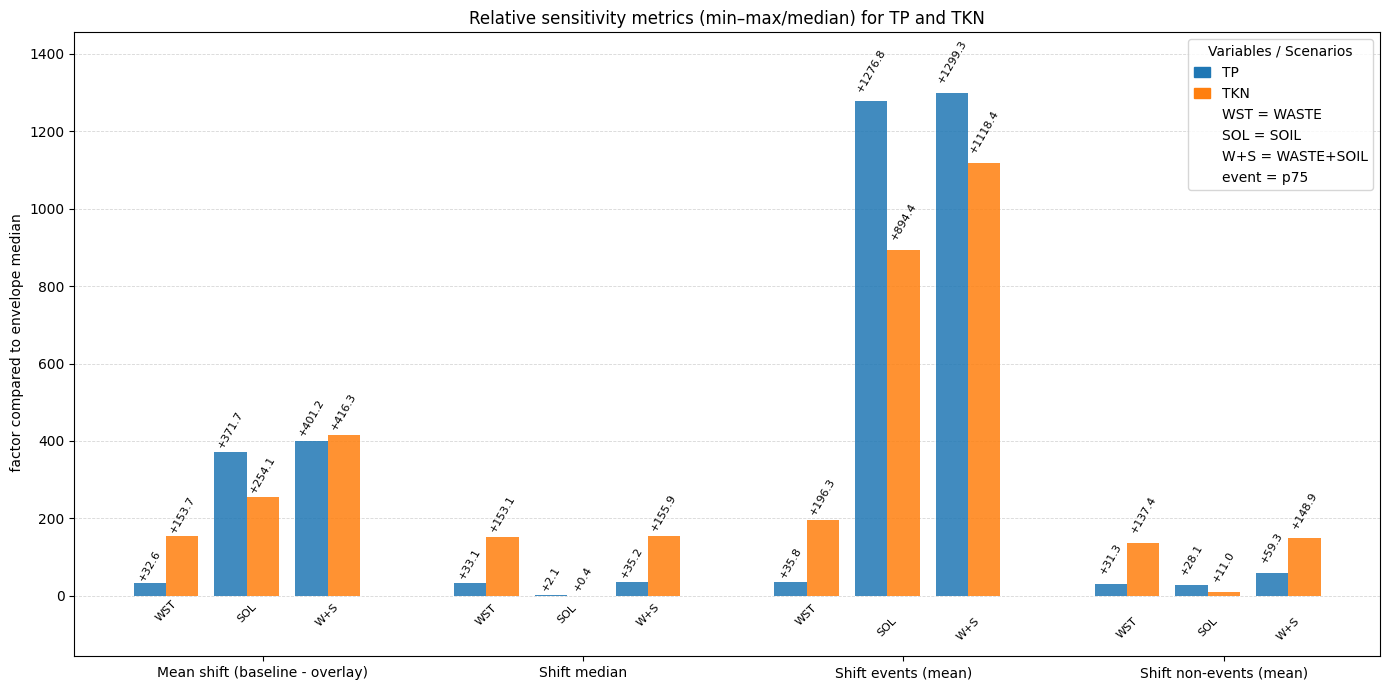

In [68]:
# Optional: display names (if you want shorter labels); otherwise omit stat_label_map


# Ask for metrics using the human-readable labels from semantic_label_map.
ch2_semantic_labels = [
    "Mean shift (baseline - overlay)", #"Shift mean", 
    "Shift median", 
    "Shift events (mean)", 
    "Shift non-events (mean)",
]

# format_mode options:
# - "metadata": keep numeric values and add '__format' to each metric block.
# - "values": store formatted strings directly and omit '__format'.

ch_2_auto_metrics = build_metrics_dict_from_stat_exports(
    generated_specs, #generated_specs, example_export_specs,
    ch2_semantic_labels,
    semantic_label_map=example_semantic_label_map,
    scenario_order=["WASTE", "SOIL", "WASTE+SOIL"],
    variable_order=["TP", "TKN"],
    format_mode="metadata",
    #format_mode="values",
    verbose=False,
 )





stat_display_names = {k: k for k in stats["metrics"].keys()}

fig, ax = plot_nested_sensitivity_bars(
    ch_2_auto_metrics,  # or ch_2,
    # stats_order=stats_order_first_ch,  # optional
    title="Relative sensitivity metrics (min–max/median) for TP and TKN",
    y_label=" factor compared to envelope median",
    figsize=(14, 7),
    abbreviations={"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S", "p75":"event"},
    #value_format=lambda v: f"{v:.1f}",   # or omit and use annotate_decimals
    #annotate_decimals=2,
    #format_map=format_val,
    #bar_alpha=0.85,
    annotate_rotation=60,
    #scenario_label_rotation=45,
    #scenario_spacing=0.06,
    #bar_width=0.12,
    #bottom_margin_for_labels=0.12,
    #stat_label_map=stat_display_names
)


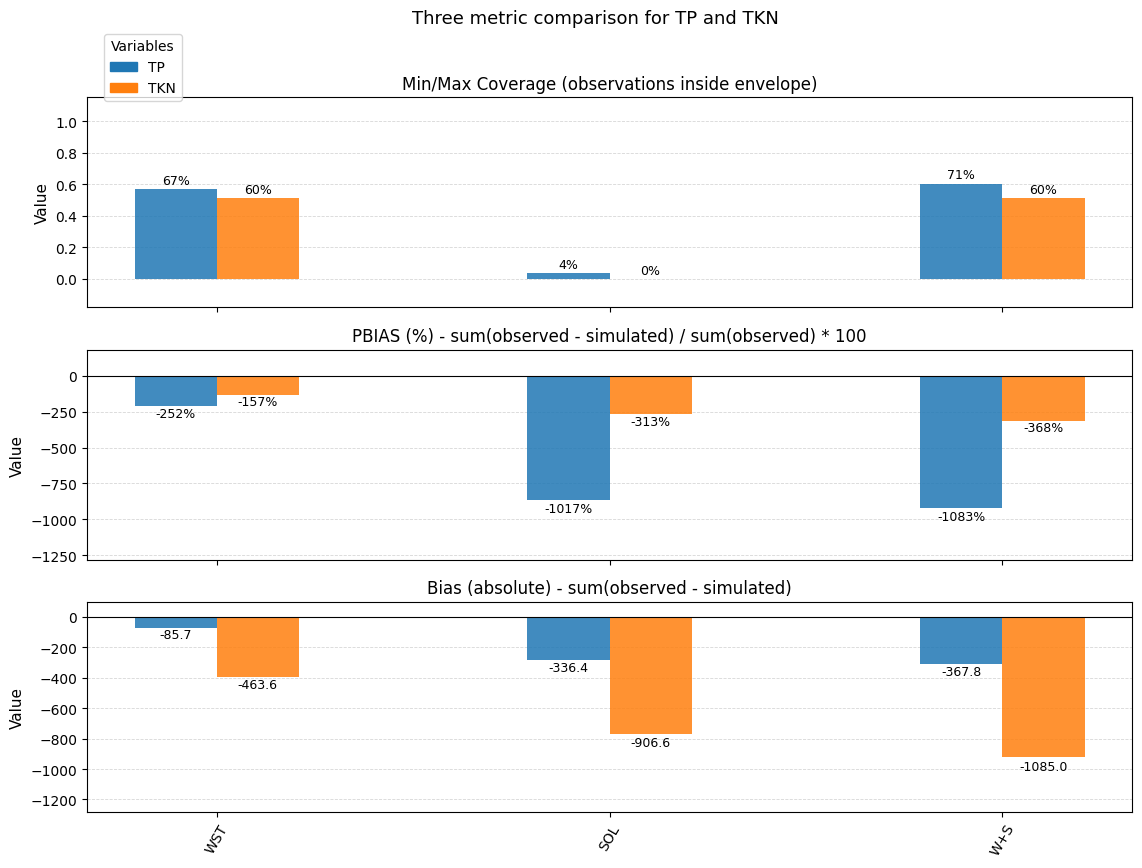

In [69]:
three_metric_specs = [
    {"title": "Min/Max Coverage (observations inside envelope)"},
    {"title": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
    {"title": "Bias (absolute) - sum(observed - simulated)"},
]

three_metric_semantic_label_map = {
    **semantic_label_map,
    **example_semantic_label_map,
    "coverage100": {
        "label": "Min/Max Coverage (observations inside envelope)",
        "path": ("same_day", "coverage100"),
    },
    "PBIAS%": {
        "label": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100",
        "path": ("same_day", "PBIAS%"),
    },
    "Bias(obs-pred)": {
        "label": "Bias (absolute) - sum(observed - simulated)",
        "path": ("same_day", "Bias(obs-pred)"),
    },
}

fig, ax, three_metric_stats = plot_three_metric_comparison(
    generated_specs, #generated_specs, example_export_specs,
    metric_specs=three_metric_specs,
    semantic_label_map=three_metric_semantic_label_map,
    scenario_order=["WASTE", "SOIL", "WASTE+SOIL"],
    variable_order=["TP", "TKN"],
    title="Three metric comparison for TP and TKN",
    y_label="Value",
    figsize=(12, 9),
    abbreviations={"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S"},
    annotate_rotation=60,
    verbose=False,
)
plt.show()